In [1]:
# Importing libraries 
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
# Import data 
diabetes_df = pd.read_csv("/kaggle/input/datasets/akshaydattatraykhare/diabetes-dataset/diabetes.csv")
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


<Axes: >

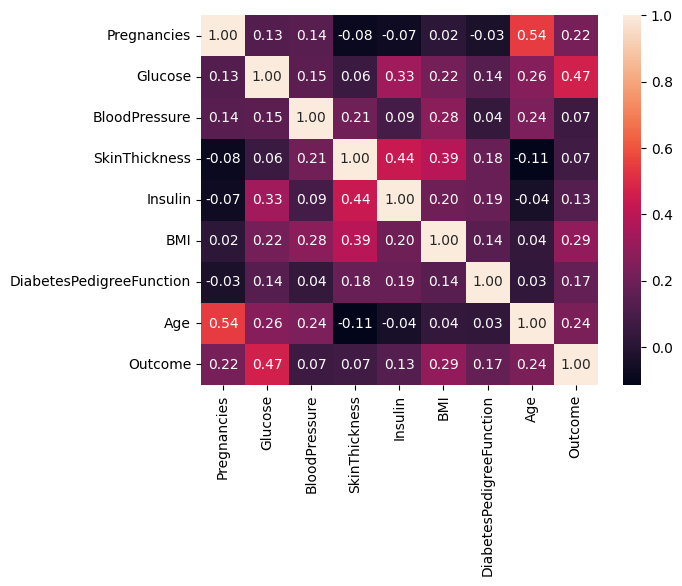

In [3]:
# Heat map of data-set 
sns.heatmap(diabetes_df.corr(), annot=True, fmt=".2f")

<Axes: xlabel='Glucose', ylabel='Density'>

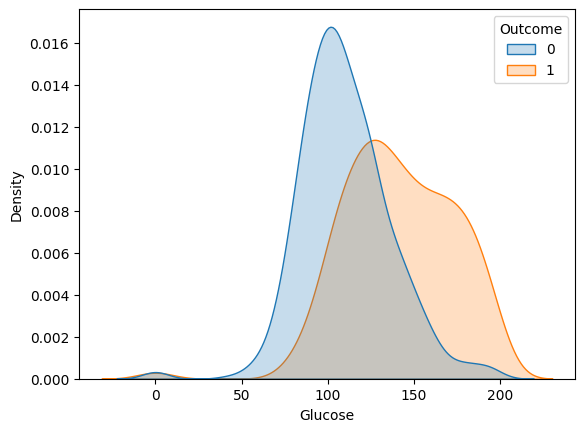

In [4]:
# Density plot of important feature with Outcome
sns.kdeplot(data=diabetes_df, x="Glucose", hue="Outcome", fill=True, common_norm=False)

<Axes: xlabel='Outcome', ylabel='Glucose'>

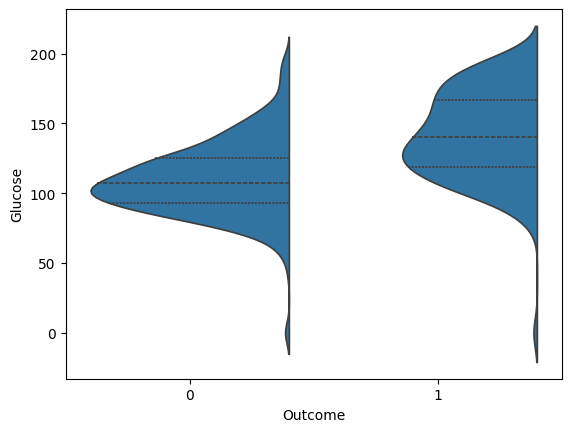

In [5]:
sns.violinplot(data=diabetes_df, x="Outcome", y="Glucose", fill=True, split=True, inner="quart")

In [6]:
# Outliers per columns 
numeric_cols = diabetes_df.select_dtypes(include=["number"]).columns
for col in numeric_cols:
    Q1 = diabetes_df[col].quantile(0.25)
    Q3 = diabetes_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((diabetes_df[col] < lower_bound) | (diabetes_df[col] > upper_bound)).sum()
    outlier_perc = (outlier_count / len(diabetes_df)) * 100 

    print(f"Column : {col:<25} , Outliers : {str(outlier_count).center(3)} , Percentage : {outlier_perc:.2f}")

Column : Pregnancies               , Outliers :  4  , Percentage : 0.52
Column : Glucose                   , Outliers :  5  , Percentage : 0.65
Column : BloodPressure             , Outliers :  45 , Percentage : 5.86
Column : SkinThickness             , Outliers :  1  , Percentage : 0.13
Column : Insulin                   , Outliers :  34 , Percentage : 4.43
Column : BMI                       , Outliers :  19 , Percentage : 2.47
Column : DiabetesPedigreeFunction  , Outliers :  29 , Percentage : 3.78
Column : Age                       , Outliers :  9  , Percentage : 1.17
Column : Outcome                   , Outliers :  0  , Percentage : 0.00


In [7]:
# Data cleaning : handling 0 values 
cleaned_df = diabetes_df.copy()

for col in cleaned_df.select_dtypes(include=["number"]).columns:
    if col in ["Outcome", "Pregnancies"]:
        continue
        
    skew_val = cleaned_df[col].skew()
    cleaned_df[col] = cleaned_df[col].replace(0, np.nan)
    
    if abs(skew_val) < 0.5:
        mean_val = cleaned_df[col].mean()
        cleaned_df[col] = cleaned_df[col].fillna(mean_val)
    else:
        median_val = cleaned_df[col].median()
        cleaned_df[col] = cleaned_df[col].fillna(median_val)

# Features 
X = cleaned_df.drop(columns=["Outcome"]).copy()
# Labels 
y = cleaned_df["Outcome"].copy()

In [8]:
# Splitting data in training and testing and valdiation (80, 20, 20)%
from sklearn.model_selection import train_test_split

# split data in train(80%) and test(20%)
X_train, X_test, y_train, y_test = train_test_split(
    X , y,
    test_size=0.20,
    random_state=67,
    stratify=y
)
# split train to training(60%) and validation(20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    train_size=0.25,
    random_state=20,
    stratify=y_train
)


In [9]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 3.0 MB/s eta 0:00:00


In [10]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

models, predictions = clf.fit(X_train, X_val, y_train, y_val)

print(models[["Accuracy", "ROC AUC", "F1 Score", "Time Taken"]].sort_values(by="Accuracy", ascending=False))

                               Accuracy   ROC AUC  F1 Score  Time Taken
Model                                                                  
RidgeClassifier                0.752711  0.831284  0.740210    0.026115
RandomForestClassifier         0.752711  0.821542  0.740909    0.180377
LinearSVC                      0.752711  0.828758  0.741590    0.027910
LinearDiscriminantAnalysis     0.752711  0.831263  0.742254    0.041542
QuadraticDiscriminantAnalysis  0.750542  0.798903  0.742802    0.031892
RidgeClassifierCV              0.748373  0.832547  0.735652    0.024252
GaussianNB                     0.748373  0.818509  0.742547    0.022419
LogisticRegression             0.746204  0.826522  0.733008    0.032657
KNeighborsClassifier           0.744035  0.778747  0.738650    0.032138
NearestCentroid                0.744035  0.831553  0.746310    0.033167
ExtraTreesClassifier           0.744035  0.809658  0.731095    0.153108
SVC                            0.744035  0.822402  0.723722    0

In [11]:
# KNN 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

max_neighbors = 12
train_scores = []
val_scores = []
test_scores = []

for i in range(1,max_neighbors):
    
    model = KNeighborsClassifier(n_neighbors=i, weights="uniform")

    # train model on training data 
    model.fit(X_train, y_train)
    
    # training scores 
    train_predict = model.predict(X_train)
    train_predict_probab = model.predict_proba(X_train)[:, 1]

    train_accuracy = accuracy_score(y_train, train_predict)
    train_roc_auc = roc_auc_score(y_train, train_predict_probab)
    
    train_scores.append([train_accuracy, train_roc_auc])

    # validation scores 
    val_predict = model.predict(X_val)
    val_predict_probab = model.predict_proba(X_val)[:, 1]

    val_accuracy = accuracy_score(y_val, val_predict)
    val_roc_auc = roc_auc_score(y_val, val_predict_probab)
    
    val_scores.append([val_accuracy, val_roc_auc])

    # testing scores 
    test_predict = model.predict(X_test)
    test_predict_probab = model.predict_proba(X_test)[:, 1]

    test_accuracy = accuracy_score(y_test, test_predict)
    test_roc_auc = roc_auc_score(y_test, test_predict_probab)
    
    test_scores.append([test_accuracy, test_roc_auc])

train_accuracies = [score[0] for score in train_scores]
val_accuracies = [score[0] for score in val_scores]
test_accuracies = [score[0] for score in test_scores]

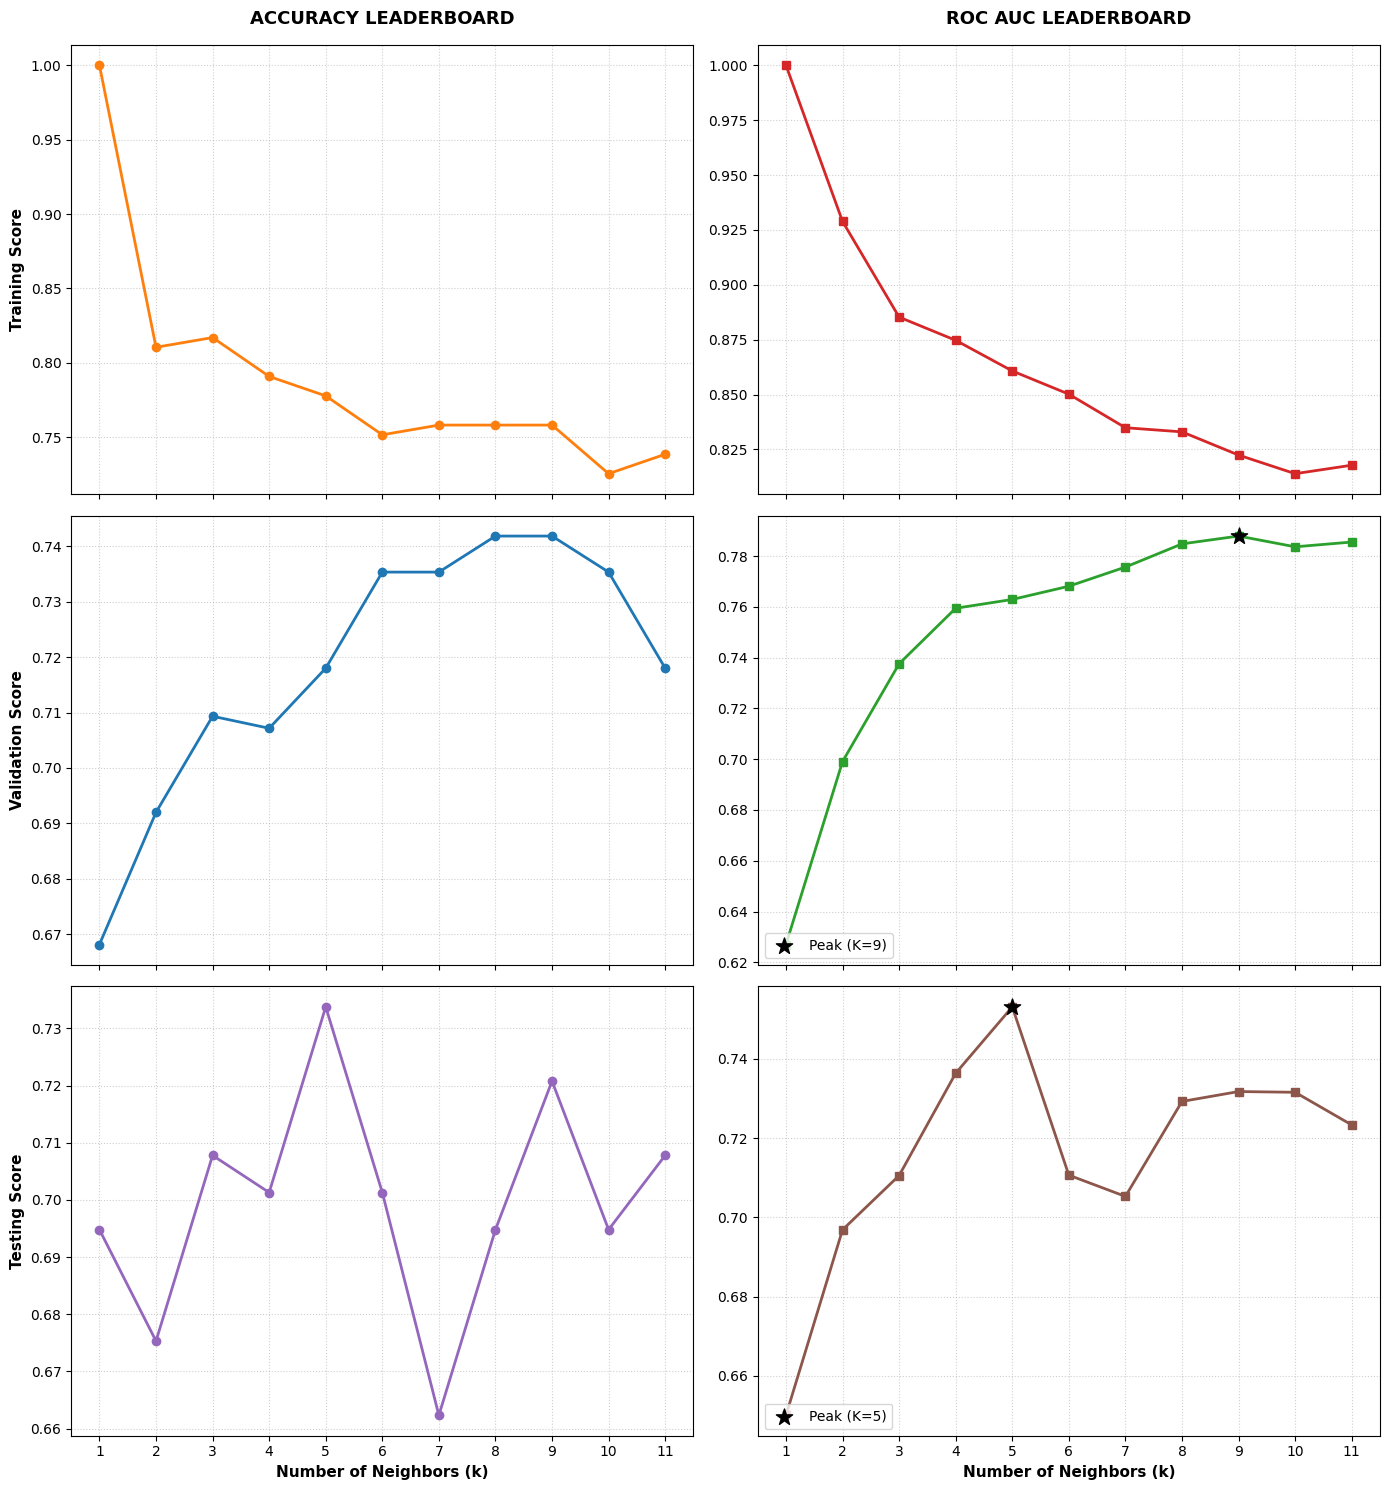

In [12]:
train_arr = np.array(train_scores)
val_arr = np.array(val_scores)
test_arr = np.array(test_scores)
neighbors = list(range(1, 12))

datasets = [
    {"name": "Training", "data": train_arr, "acc_color": "#ff7f0e", "auc_color": "#d62728"},
    {"name": "Validation", "data": val_arr, "acc_color": "#1f77b4", "auc_color": "#2ca02c"},
    {"name": "Testing", "data": test_arr, "acc_color": "#9467bd", "auc_color": "#8c564b"}
]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 15), sharex=True)

for row_idx, ds in enumerate(datasets):
    ax_acc = axes[row_idx, 0]
    ax_auc = axes[row_idx, 1]
    
    ax_acc.plot(neighbors, ds["data"][:, 0], marker="o", color=ds["acc_color"], linewidth=2)
    ax_acc.set_ylabel(f"{ds['name']} Score", fontsize=11, weight="bold")
    ax_acc.grid(True, linestyle=":", alpha=0.6)
    
    if row_idx == 0:
        ax_acc.set_title("ACCURACY LEADERBOARD", fontsize=13, weight="bold", pad=15)
        
    ax_auc.plot(neighbors, ds["data"][:, 1], marker="s", color=ds["auc_color"], linewidth=2)
    ax_auc.grid(True, linestyle=":", alpha=0.6)
    
    if row_idx == 0:
        ax_auc.set_title("ROC AUC LEADERBOARD", fontsize=13, weight="bold", pad=15)
        
    if row_idx > 0:
        best_idx = np.argmax(ds["data"][:, 1])
        ax_auc.scatter(neighbors[best_idx], ds["data"][best_idx, 1], 
                       color="black", marker="*", s=150, zorder=5, label=f"Peak (K={neighbors[best_idx]})")
        ax_auc.legend(loc="lower left")

# Manually configure the bottom axes to avoid loop syntax bugs
axes[2, 0].set_xticks(neighbors)
axes[2, 0].set_xlabel("Number of Neighbors (k)", fontsize=11, weight="bold")

axes[2, 1].set_xticks(neighbors)
axes[2, 1].set_xlabel("Number of Neighbors (k)", fontsize=11, weight="bold")

plt.tight_layout()

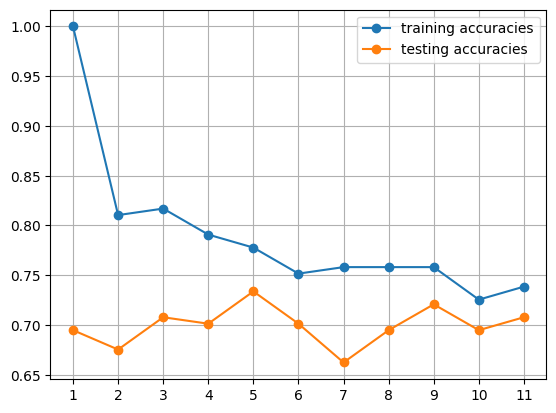

In [13]:
# train and test combined line plot 
plt.plot(range(1,12), train_accuracies, label="training accuracies", marker="o")
plt.plot(range(1,12), test_accuracies, label="testing accuracies", marker="o")
plt.xticks(range(1,12))
plt.legend()
plt.grid(True)

In [14]:
##### final K = 5 from the above graph 
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

# Training 
train_predict = knn_model.predict(X_train)
train_predict_probab = knn_model.predict_proba(X_train)[: ,1]

train_accuracy = accuracy_score(y_train, train_predict)
train_roc_auc = roc_auc_score(y_train, train_predict_probab)

# Testing
test_predict = knn_model.predict(X_test)
test_predict_probab = knn_model.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, test_predict)
test_roc_auc = roc_auc_score(y_test, test_predict_probab)

print("Training Results:")
print(f"Accuracy : {train_accuracy:<4.2f}, ROC AUC : {train_roc_auc:<4.2f}")
print("Testing Results:")
print(f"Accuracy : {test_accuracy:<4.2f}, ROC AUC : {test_roc_auc:<4.2f}")

Training Results:
Accuracy : 0.78, ROC AUC : 0.86
Testing Results:
Accuracy : 0.73, ROC AUC : 0.75


In [15]:
from sklearn.ensemble import RandomForestClassifier

# random forest classifier 
rf_model = RandomForestClassifier(random_state=42, max_depth=3)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on your test data
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 4. Print the final test metrics
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"Random Forest Test ROC AUC: {roc_auc_score(y_test, rf_probs):.4f}\n")


Random Forest Test Accuracy: 0.7338
Random Forest Test ROC AUC: 0.7778



In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Scale data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Optimized MLP for small tabular datasets
mlp_optimized = MLPClassifier(
    hidden_layer_sizes=(64, 32), # Two hidden layers
    solver='lbfgs',              # FIX: Best solver for small datasets
    alpha=1e-3,                  # L2 penalty regularization to prevent overfitting
    random_state=67,
    max_iter=1000                # Extra breathing room to converge
)

# 3. Fit and Predict
mlp_optimized.fit(X_train_scaled, y_train)
mlp_preds = mlp_optimized.predict(X_test_scaled)
mlp_probs = mlp_optimized.predict_proba(X_test_scaled)[:, 1]

# 4. Print metrics
print("=== OPTIMIZED MLP TEST METRICS ===")
print(f"MLP Test Accuracy: {accuracy_score(y_test, mlp_preds):.4f}")
print(f"MLP Test ROC AUC: {roc_auc_score(y_test, mlp_probs):.4f}\n")


=== OPTIMIZED MLP TEST METRICS ===
MLP Test Accuracy: 0.6169
MLP Test ROC AUC: 0.6296

